# EEG_16b — Subject Clustering v2: P022 rimosso, k=2 forzato

**Differenze rispetto a EEG_16**:
- **P022 escluso** (era singleton outlier in k=3 — distorce il clustering)
- **k=2 forzato** (confronto pulito C0 vs C1 sui 73 soggetti rimanenti)
- **§2 NUOVO**: perché P022 è un outlier (posizione PCA, distanza dai cluster, fingerprint feature)
- **§9 NUOVO**: PCA loadings → quali connessioni electrode-pair guidano la separazione C0/C1
- **§10 NUOVO**: mappa differenza aggregata per elettrodo → quale regione cerebrale distingue i due cluster

**Domanda scientifica**: perché i soggetti si dividono in due cluster distinti?
Cosa c'è di diverso nella topografia di connettività di C0 vs C1?

In [ ]:
import json, logging, math, re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('eeg16b')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
# Ckpt dir separato da eeg16 per non sovrascrivere cache esistente
CKPT_DIR = project_root / 'models' / 'eeg16'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

ACC_FILE_12 = project_root / 'figures' / 'eeg12_subject_ranking.csv'
ACC_FILE_13 = project_root / 'figures' / 'eeg13b_subject_ranking.csv'

METRIC       = 'abs_pcc'
N_CHAN       = 61
N_TRIU       = N_CHAN * (N_CHAN - 1) // 2   # 1830
K_FORCED     = 2          # k=2 forzato — no grid search
EXCLUDE_SUBJ = [22]       # P022 outlier singleton rimosso
RANDOM_SEED  = 42

log.info(f'project_root = {project_root}')
log.info(f'Metrica: {METRIC} | N_TRIU: {N_TRIU} | k forzato: {K_FORCED}')
log.info(f'Soggetti esclusi: {[f"P{s:03d}" for s in EXCLUDE_SUBJ]}')

## §1 — Caricamento feature per soggetto

Carica le cache già prodotte da EEG_16 (stessi file `.npz`).
Poi filtra P022 e tutti i soggetti in `EXCLUDE_SUBJ`.

In [ ]:
_PAT = re.compile(r'^P(\d+)_S(\d+)$')

def build_index(metric):
    root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
    idx  = defaultdict(list)
    if not root.exists():
        log.warning(f'Directory non trovata: {root}')
        return idx
    for p in sorted(root.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m:
            idx[int(m.group(1))].append(p)
    return idx

IDX      = build_index(METRIC)
ALL_SUBJ = sorted(IDX.keys())

GRAPH_CACHE = CKPT_DIR / f'feat_graph_{METRIC}.npz'
HG_CACHE    = CKPT_DIR / f'feat_hg_{METRIC}.npz'
triu_idx    = np.triu_indices(N_CHAN, k=1)

# ── Carica cache (prodotta da eeg16) ─────────────────────────────────────────
assert GRAPH_CACHE.exists() and HG_CACHE.exists(), \
    "Cache non trovata — esegui prima EEG_16 per produrre feat_graph_abs_pcc.npz e feat_hg_abs_pcc.npz"

_g = np.load(GRAPH_CACHE); FEAT_G_ALL = _g['feats']; SUBJ_G_ALL = _g['subj_ids'].tolist()
_h = np.load(HG_CACHE);    FEAT_H_ALL = _h['feats']; SUBJ_H_ALL = _h['subj_ids'].tolist()
log.info(f'Cache caricata — Grafi: {FEAT_G_ALL.shape}  Ipergrafi: {FEAT_H_ALL.shape}')

# ── Salva versione COMPLETA per analisi outlier §2 ─────────────────────────
FEAT_G_FULL = FEAT_G_ALL.copy()
SUBJ_G_FULL = SUBJ_G_ALL.copy()
FEAT_H_FULL = FEAT_H_ALL.copy()
SUBJ_H_FULL = SUBJ_H_ALL.copy()

# ── Filtra soggetti esclusi ───────────────────────────────────────────────────
def filter_subj(feats, subj_ids, exclude):
    keep = [i for i, s in enumerate(subj_ids) if s not in exclude]
    return feats[keep], [subj_ids[i] for i in keep]

FEAT_G, SUBJ_G = filter_subj(FEAT_G_ALL, SUBJ_G_ALL, EXCLUDE_SUBJ)
FEAT_H, SUBJ_H = filter_subj(FEAT_H_ALL, SUBJ_H_ALL, EXCLUDE_SUBJ)
log.info(f'Dopo esclusione P022 — Grafi: {FEAT_G.shape} ({len(SUBJ_G)} soggetti)')
log.info(f'Dopo esclusione P022 — Ipergrafi: {FEAT_H.shape} ({len(SUBJ_H)} soggetti)')

## §2 — Perché P022 è un outlier?

Prima di escluderlo, capire cosa lo rende anomalo:
- **Posizione nello spazio PCA** su tutti e 74 i soggetti
- **Distanza euclidea** di P022 dai due cluster principali
- **Feature fingerprint**: confronto vettore P022 vs media C0 e media C1 nei 1830 feature (top deviazioni)

In [ ]:
# ── PCA su tutti e 74 soggetti ────────────────────────────────────────────────
scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(FEAT_G_FULL)
pca_full = PCA(n_components=min(20, len(SUBJ_G_FULL) - 1), random_state=RANDOM_SEED)
Z_full = pca_full.fit_transform(X_full)

# Cluster k=2 su tutti 74 per trovare a quale cluster "apparterrebbe" P022
km_full = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED)
labels_full = km_full.fit_predict(Z_full)

# Indice di P022
p022_idx = SUBJ_G_FULL.index(22)
p022_z   = Z_full[p022_idx]

# Distanza di P022 dai due centroidi
dist_c0 = np.linalg.norm(p022_z - km_full.cluster_centers_[0])
dist_c1 = np.linalg.norm(p022_z - km_full.cluster_centers_[1])

# Distanza di ogni soggetto dal proprio centroide
own_dists = np.array([
    np.linalg.norm(Z_full[i] - km_full.cluster_centers_[labels_full[i]])
    for i in range(len(SUBJ_G_FULL))
])
p022_own_dist = own_dists[p022_idx]
percentile_p022 = (own_dists < p022_own_dist).mean() * 100

log.info(f'P022 — cluster assegnato: C{labels_full[p022_idx]}')
log.info(f'P022 — distanza da C0: {dist_c0:.3f}  da C1: {dist_c1:.3f}')
log.info(f'P022 — distanza dal proprio centroide: {p022_own_dist:.3f}  (percentile {percentile_p022:.0f}th)')

# ── Plot 1: PCA 2D tutti 74, P022 evidenziato ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('P022 — Analisi Outlier (PCA su tutti 74 soggetti)', fontsize=13, fontweight='bold')

ax = axes[0]
pal2 = plt.cm.tab10([0, 0.1])
for c in [0, 1]:
    mask = labels_full == c
    ax.scatter(Z_full[mask, 0], Z_full[mask, 1],
               color=pal2[c], s=55, alpha=0.7, label=f'C{c} (n={mask.sum()})',
               edgecolors='white', linewidths=0.4)
    for i in np.where(mask)[0]:
        if SUBJ_G_FULL[i] != 22:
            ax.annotate(f'P{SUBJ_G_FULL[i]:03d}', (Z_full[i, 0], Z_full[i, 1]),
                        fontsize=4.5, xytext=(2, 2), textcoords='offset points', alpha=0.6)
# Evidenzia P022
ax.scatter(p022_z[0], p022_z[1], color='red', s=180, zorder=5,
           edgecolors='black', linewidths=1.5, marker='*', label='P022 (outlier)')
ax.annotate('P022', (p022_z[0], p022_z[1]), fontsize=9, fontweight='bold',
            color='red', xytext=(5, 5), textcoords='offset points')
# Centroidi
ax.scatter(km_full.cluster_centers_[:, 0], km_full.cluster_centers_[:, 1],
           marker='X', s=150, color=['tab:blue', 'tab:orange'], edgecolors='black',
           linewidths=1, zorder=6, label='Centroidi')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'k=2 su 74 soggetti\nP022: dist_C0={dist_c0:.2f}  dist_C1={dist_c1:.2f}  (p{percentile_p022:.0f}th per isolamento)')
ax.legend(fontsize=7); ax.grid(alpha=0.25)

# ── Plot 2: distanza di ogni soggetto dal proprio centroide (ranking) ─────────
ax2 = axes[1]
sorted_idx = np.argsort(own_dists)[::-1]
colors_bar = ['red' if SUBJ_G_FULL[i] == 22 else 'steelblue' for i in sorted_idx]
ax2.bar(range(len(sorted_idx)), own_dists[sorted_idx], color=colors_bar, alpha=0.8)
p022_rank = int(np.where(sorted_idx == p022_idx)[0][0])
ax2.axvline(p022_rank, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Soggetti (ordinati per distanza decrescente)')
ax2.set_ylabel('Distanza dal centroide (spazio PCA)')
ax2.set_title(f'P022 è rank #{p022_rank + 1} per isolamento dal centroide')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_p022_outlier_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fingerprint feature: dove P022 si discosta di più dalla media globale ─────
mean_all   = FEAT_G_FULL.mean(axis=0)
delta_p022 = FEAT_G_FULL[p022_idx] - mean_all

top_k = 20
top_idx_feat = np.argsort(np.abs(delta_p022))[::-1][:top_k]

def feat_to_elec_pair(feat_indices, n_chan=61):
    rows, cols = np.triu_indices(n_chan, k=1)
    return [(rows[i], cols[i]) for i in feat_indices]

top_pairs = feat_to_elec_pair(top_idx_feat)
vals = delta_p022[top_idx_feat]

fig, ax = plt.subplots(figsize=(12, 4))
colors_feat = ['crimson' if v > 0 else 'steelblue' for v in vals]
pair_labels = [f'E{r}-E{c}' for r, c in top_pairs]
ax.barh(range(top_k), vals[::-1], color=colors_feat[::-1], alpha=0.8)
ax.set_yticks(range(top_k))
ax.set_yticklabels(pair_labels[::-1], fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('P022 feature − media popolazione')
ax.set_title(f'Top {top_k} deviazioni di P022 dalla media\n(rosso = P022 più connesso, blu = meno connesso)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_p022_feature_fingerprint.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nP022 si discosta dalla media su {(np.abs(delta_p022) > delta_p022.std()).sum()} / {len(delta_p022)} feature')
print(f'Max deviazione: {delta_p022.max():.4f}  Min: {delta_p022.min():.4f}')

## §3 — Clustering k=2 su feature GRAFO (senza P022)

StandardScaler → PCA 20 componenti → K-Means k=2 forzato.
Silhouette calcolata solo per confronto con EEG_16.

In [ ]:
scaler_g = StandardScaler()
X_g = scaler_g.fit_transform(FEAT_G)
pca_g = PCA(n_components=min(20, len(SUBJ_G) - 1), random_state=RANDOM_SEED)
Z_g   = pca_g.fit_transform(X_g)
log.info(f'Varianza spiegata PCA grafo (20 comp): {pca_g.explained_variance_ratio_.sum():.1%}')

# k=2 forzato
k_best_g = K_FORCED
LABELS_G  = KMeans(n_clusters=k_best_g, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_g)
sil_g2    = silhouette_score(Z_g, LABELS_G)
log.info(f'Grafo k=2: silhouette={sil_g2:.3f}  |  cluster sizes: {dict(zip(*np.unique(LABELS_G, return_counts=True)))}')

PALETTE_G = plt.cm.tab10(np.linspace(0, 0.15, k_best_g))

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(f'Clustering k=2 — Feature GRAFO (adj, {METRIC}, senza P022)\nsil={sil_g2:.3f}',
             fontsize=12, fontweight='bold')
for c in range(k_best_g):
    mask = LABELS_G == c
    ax.scatter(Z_g[mask, 0], Z_g[mask, 1], label=f'C{c} (n={mask.sum()})',
               s=70, alpha=0.85, color=PALETTE_G[c], edgecolors='white', linewidths=0.5)
    for i in np.where(mask)[0]:
        ax.annotate(f'P{SUBJ_G[i]:03d}', (Z_g[i, 0], Z_g[i, 1]),
                    fontsize=5, xytext=(2, 2), textcoords='offset points')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_clustering_graph_k2.png', dpi=150, bbox_inches='tight')
plt.show()

## §4 — Clustering k=2 su feature IPERGRAFO (senza P022)

In [ ]:
scaler_h = StandardScaler()
X_h = scaler_h.fit_transform(FEAT_H)
pca_h = PCA(n_components=min(20, len(SUBJ_H) - 1), random_state=RANDOM_SEED)
Z_h   = pca_h.fit_transform(X_h)
log.info(f'Varianza spiegata PCA ipergrafo (20 comp): {pca_h.explained_variance_ratio_.sum():.1%}')

k_best_h = K_FORCED
LABELS_H  = KMeans(n_clusters=k_best_h, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_h)
sil_h2    = silhouette_score(Z_h, LABELS_H)
log.info(f'Ipergrafo k=2: silhouette={sil_h2:.3f}  |  cluster sizes: {dict(zip(*np.unique(LABELS_H, return_counts=True)))}')

PALETTE_H = plt.cm.tab10(np.linspace(0.5, 0.65, k_best_h))

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(f'Clustering k=2 — Feature IPERGRAFO (H·Hᵀ, {METRIC}, senza P022)\nsil={sil_h2:.3f}',
             fontsize=12, fontweight='bold')
for c in range(k_best_h):
    mask = LABELS_H == c
    ax.scatter(Z_h[mask, 0], Z_h[mask, 1], label=f'C{c} (n={mask.sum()})',
               s=70, alpha=0.85, color=PALETTE_H[c], edgecolors='white', linewidths=0.5)
    for i in np.where(mask)[0]:
        ax.annotate(f'P{SUBJ_H[i]:03d}', (Z_h[i, 0], Z_h[i, 1]),
                    fontsize=5, xytext=(2, 2), textcoords='offset points')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_clustering_hypergraph_k2.png', dpi=150, bbox_inches='tight')
plt.show()

## §5 — Caricamento bAcc post-hoc

In [22]:
acc_data = {}
for label, fpath in [('EEG_12', ACC_FILE_12), ('EEG_13', ACC_FILE_13)]:
    if fpath.exists():
        df = pd.read_csv(fpath)
        if 'Subject' in df.columns:
            df['sid'] = df['Subject'].str.extract(r'(\d+)').astype(int)
        col = 'Test bAcc' if 'Test bAcc' in df.columns else 'test_bacc'
        acc_data[label] = dict(zip(df['sid'], df[col]))
        log.info(f'{label}: {len(acc_data[label])} soggetti')
    else:
        log.warning(f'{label} non trovato')

acc12 = acc_data.get('EEG_12', {})
acc13 = acc_data.get('EEG_13', {})
ACC   = acc13 if acc13 else acc12
log.info(f'Accuracy primaria: {"EEG_13" if acc13 else "EEG_12"} ({len(ACC)} soggetti)')

14:55:53 INFO     EEG_12: 73 soggetti
14:55:53 INFO     EEG_13: 73 soggetti
14:55:53 INFO     Accuracy primaria: EEG_13 (73 soggetti)


## §6 — Post-hoc: cluster GRAFO vs bAcc

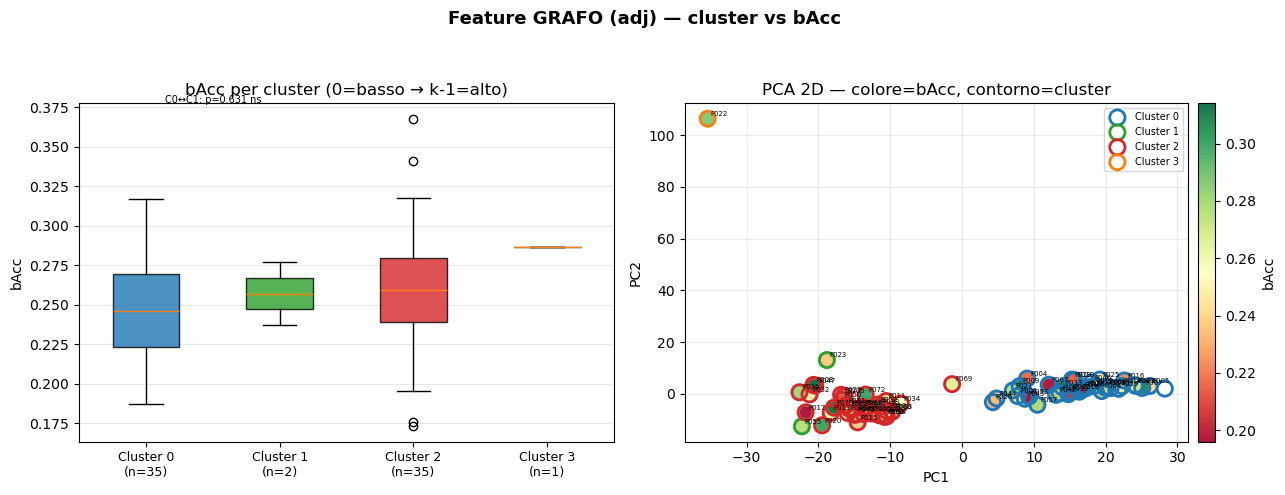

In [23]:
def postHoc(labels, subj_ids, Z, palette, acc_dict, source_name, save_stem):
    k = len(set(labels))
    clust_accs = defaultdict(list)
    for i, sid in enumerate(subj_ids):
        if sid in acc_dict:
            clust_accs[labels[i]].append(acc_dict[sid])

    # Riordina cluster per acc media crescente
    order  = sorted(clust_accs, key=lambda c: np.mean(clust_accs[c]) if clust_accs[c] else 0)
    remap  = {old: new for new, old in enumerate(order)}
    lbl_r  = np.array([remap[l] for l in labels])
    acc_r  = {remap[c]: v for c, v in clust_accs.items()}
    pal_r  = [palette[order[c]] for c in range(k)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{source_name} — cluster vs bAcc', fontsize=13, fontweight='bold')

    # ── Boxplot ───────────────────────────────────────────────────────────────
    ax = axes[0]
    bp = ax.boxplot([acc_r.get(c, []) for c in range(k)],
                    patch_artist=True, widths=0.5, notch=False)
    for patch, col in zip(bp['boxes'], pal_r):
        patch.set_facecolor(col); patch.set_alpha(0.8)
    ax.set_xticklabels([f'Cluster {c}\n(n={len(acc_r.get(c,[]))})' for c in range(k)], fontsize=9)
    ax.set_ylabel('bAcc'); ax.set_title('bAcc per cluster (0=basso → k-1=alto)')
    ax.grid(axis='y', alpha=0.3)

    # Annotazione p-value Mann-Whitney
    all_vals = [v for vlist in acc_r.values() for v in vlist]
    y_top = max(all_vals) + 0.01 if all_vals else 0.4
    pairs = [(ci, cj) for ci in range(k) for cj in range(ci + 1, k)]
    for offset, (ci, cj) in enumerate(pairs):
        a, b = acc_r.get(ci, []), acc_r.get(cj, [])
        if len(a) >= 2 and len(b) >= 2:
            _, pval = mannwhitneyu(a, b, alternative='two-sided')
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            y = y_top + offset * 0.018
            ax.annotate(f'C{ci}↔C{cj}: p={pval:.3f} {star}',
                        xy=(1.5, y), fontsize=7, ha='center', color='black')

    # ── PCA 2D colorato per bAcc ──────────────────────────────────────────────
    ax2 = axes[1]
    accs_vec = np.array([acc_dict.get(sid, np.nan) for sid in subj_ids])
    valid    = ~np.isnan(accs_vec)
    sc = ax2.scatter(Z[valid, 0], Z[valid, 1], c=accs_vec[valid],
                     cmap='RdYlGn', s=80, alpha=0.9,
                     vmin=np.nanpercentile(accs_vec, 5),
                     vmax=np.nanpercentile(accs_vec, 95),
                     edgecolors='grey', linewidths=0.4)
    plt.colorbar(sc, ax=ax2, label='bAcc', fraction=0.04, pad=0.02)
    # Contorno cluster
    for c in range(k):
        mask = lbl_r == c
        ax2.scatter(Z[mask, 0], Z[mask, 1], s=120, facecolors='none',
                    edgecolors=pal_r[c], linewidths=2, label=f'Cluster {c}', zorder=3)
    for i in range(len(subj_ids)):
        if valid[i]:
            ax2.annotate(f'P{subj_ids[i]:03d}', (Z[i, 0], Z[i, 1]),
                         fontsize=5, xytext=(2, 2), textcoords='offset points')
    ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
    ax2.set_title('PCA 2D — colore=bAcc, contorno=cluster')
    ax2.legend(fontsize=7); ax2.grid(alpha=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(FIG_DIR / f'{save_stem}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return lbl_r

LABELS_G_R = postHoc(LABELS_G, SUBJ_G, Z_g, PALETTE_G, ACC,
                     'Feature GRAFO (adj)', 'eeg16_graph_vs_bacc')

## §7 — Post-hoc: cluster IPERGRAFO vs bAcc

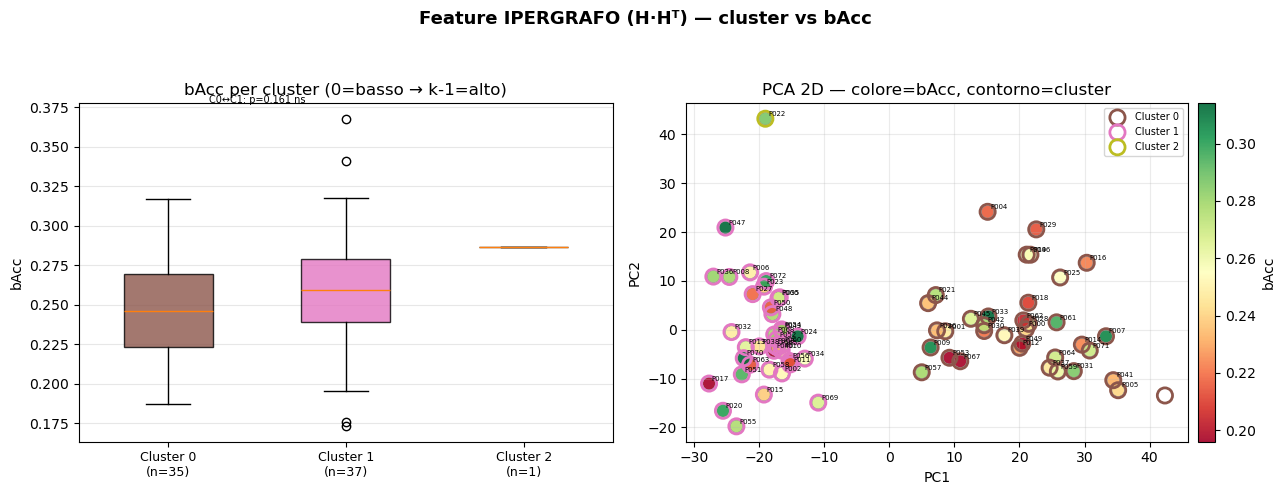

In [24]:
LABELS_H_R = postHoc(LABELS_H, SUBJ_H, Z_h, PALETTE_H, ACC,
                     'Feature IPERGRAFO (H·Hᵀ)', 'eeg16_hypergraph_vs_bacc')

## §8 — Concordanza clustering grafo vs ipergrafo (ARI)

14:55:59 INFO     Soggetti in comune grafo ∩ ipergrafo: 74
14:55:59 INFO     ARI (grafo vs ipergrafo): 0.948


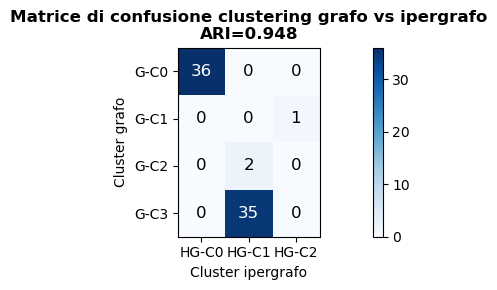

In [25]:
common = sorted(set(SUBJ_G) & set(SUBJ_H))
log.info(f'Soggetti in comune grafo ∩ ipergrafo: {len(common)}')

lbl_g_common = np.array([LABELS_G[SUBJ_G.index(s)] for s in common])
lbl_h_common = np.array([LABELS_H[SUBJ_H.index(s)] for s in common])
ari = adjusted_rand_score(lbl_g_common, lbl_h_common)
log.info(f'ARI (grafo vs ipergrafo): {ari:.3f}')

fig, ax = plt.subplots(figsize=(max(k_best_g, k_best_h) * 2.5 + 1, 3))
cm = np.zeros((k_best_g, k_best_h), dtype=int)
for g, h in zip(lbl_g_common, lbl_h_common):
    cm[g, h] += 1
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(k_best_h)); ax.set_xticklabels([f'HG-C{c}' for c in range(k_best_h)])
ax.set_yticks(range(k_best_g)); ax.set_yticklabels([f'G-C{c}' for c in range(k_best_g)])
ax.set_xlabel('Cluster ipergrafo'); ax.set_ylabel('Cluster grafo')
ax.set_title(f'Matrice di confusione clustering grafo vs ipergrafo\nARI={ari:.3f}', fontweight='bold')
for i in range(k_best_g):
    for j in range(k_best_h):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16_ari_graph_vs_hypergraph.png', dpi=150, bbox_inches='tight')
plt.show()

## §8b — Tabella riassuntiva soggetti

In [26]:
rows = []
for sid in sorted(set(SUBJ_G) | set(SUBJ_H)):
    row = {'Subject': f'P{sid:03d}',
           'cluster_graph':     LABELS_G[SUBJ_G.index(sid)] if sid in SUBJ_G else np.nan,
           'cluster_hypergraph':LABELS_H[SUBJ_H.index(sid)] if sid in SUBJ_H else np.nan,
           'bacc_EEG_12': acc12.get(sid, np.nan),
           'bacc_EEG_13': acc13.get(sid, np.nan)}
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.to_csv(FIG_DIR / 'eeg16_subject_cluster_summary.csv', index=False)

# Stampa con colorazione manuale
display_df = df_summary.copy()
print(display_df.to_string(index=False, float_format='{:.4f}'.format))

# Statistiche per cluster grafo
print('\n── Statistiche bAcc per cluster GRAFO ──')
for c in sorted(df_summary['cluster_graph'].dropna().unique()):
    sub = df_summary[df_summary['cluster_graph'] == c]['bacc_EEG_13'].dropna()
    print(f'  Cluster {int(c)}: n={len(sub)}  mean={sub.mean():.3f}  std={sub.std():.3f}  '
          f'[{sub.min():.3f}, {sub.max():.3f}]')

print('\n── Statistiche bAcc per cluster IPERGRAFO ──')
for c in sorted(df_summary['cluster_hypergraph'].dropna().unique()):
    sub = df_summary[df_summary['cluster_hypergraph'] == c]['bacc_EEG_13'].dropna()
    print(f'  Cluster {int(c)}: n={len(sub)}  mean={sub.mean():.3f}  std={sub.std():.3f}  '
          f'[{sub.min():.3f}, {sub.max():.3f}]')

Subject  cluster_graph  cluster_hypergraph  bacc_EEG_12  bacc_EEG_13
   P000              0                   0       0.2731       0.2399
   P001              0                   0       0.2500       0.2474
   P002              3                   1       0.2973       0.2528
   P003              3                   1       0.2384       0.2791
   P004              0                   0       0.2546       0.2167
   P005              0                   0       0.2567       0.2414
   P006              3                   1       0.2396       0.2490
   P007              0                   0       0.2063       0.3064
   P008              3                   1       0.2871       0.2788
   P009              0                   0       0.2607       0.3062
   P010              3                   1       0.1984       0.2471
   P011              3                   1       0.2549       0.2391
   P012              0                   0       0.2500       0.2279
   P013              3            

## §9 — PCA Loadings: quali connessioni electrode-pair guidano C0 vs C1?

PC1 separa i due cluster nello spazio ridotto. I **loadings di PC1** (pesi delle 1830 feature originali
sul primo componente principale) indicano quali coppie di elettrodi sono più discriminative.

**Interpretazione**:
- Loading alto positivo → questa coppia di elettrodi ha alta connettività nel cluster con PC1 alto
- Loading alto negativo → questa coppia ha alta connettività nel cluster con PC1 basso
- Aggregando i loadings per elettrodo → quale regione cerebrale è più "responsabile" della separazione

In [ ]:
# ── PC1 loadings del grafo ────────────────────────────────────────────────────
pc1_loadings = pca_g.components_[0]   # (1830,) — peso di ogni feature in PC1

# Top 30 coppie per |loading|
top_n = 30
top_load_idx = np.argsort(np.abs(pc1_loadings))[::-1][:top_n]
top_pairs_load = feat_to_elec_pair(top_load_idx)
top_load_vals  = pc1_loadings[top_load_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PCA Loadings — PC1 (feature GRAFO, k=2 senza P022)', fontsize=12, fontweight='bold')

ax = axes[0]
colors_load = ['crimson' if v > 0 else 'steelblue' for v in top_load_vals[::-1]]
pair_str    = [f'E{r:02d}–E{c:02d}' for r, c in top_pairs_load[::-1]]
ax.barh(range(top_n), top_load_vals[::-1], color=colors_load, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(pair_str, fontsize=7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Loading PC1')
ax.set_title(f'Top {top_n} coppie per |loading PC1|\nRosso = C alto-PC1 più connesso  |  Blu = C basso-PC1 più connesso')
ax.grid(axis='x', alpha=0.3)

# ── Aggregazione per elettrodo: somma |loading| di tutte le coppie ────────────
rows_triu, cols_triu = np.triu_indices(N_CHAN, k=1)
elec_importance = np.zeros(N_CHAN)
for feat_i, val in enumerate(pc1_loadings):
    r, c = rows_triu[feat_i], cols_triu[feat_i]
    elec_importance[r] += abs(val)
    elec_importance[c] += abs(val)

# Top 20 elettrodi per importanza
top_elec_idx = np.argsort(elec_importance)[::-1][:20]
ax2 = axes[1]
ax2.bar(range(20), elec_importance[top_elec_idx], color='steelblue', alpha=0.85)
ax2.set_xticks(range(20))
ax2.set_xticklabels([f'E{e:02d}' for e in top_elec_idx], rotation=45, fontsize=8)
ax2.set_ylabel('Importanza aggregata (Σ|loading|)')
ax2.set_title('Top 20 elettrodi — importanza in PC1\n(somma dei |loading| di tutte le coppie che includono quell\'elettrodo)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_pca_loadings_pc1.png', dpi=150, bbox_inches='tight')
plt.show()

# Stampa ranking elettrodi
print('\n── Top 15 elettrodi per importanza in PC1 (GRAFO) ──')
for rank, e in enumerate(elec_importance.argsort()[::-1][:15]):
    print(f'  #{rank+1:2d}  E{e:02d}  importance={elec_importance[e]:.4f}')

## §10 — Mappa differenza per elettrodo: C1 − C0

Per ogni elettrodo `i`: `strength_diff[i] = mean_j(|adj_C1[i,j] − adj_C0[i,j]|)`

Mostra quale elettrodo ha la connettività più **diversa** tra i due cluster.
Positivo = C1 ha più connettività da quell'elettrodo; negativo = C0 ne ha di più.

Questa è la risposta alla domanda: **in quale regione cerebrale differiscono i due cluster?**

In [ ]:
def vec_to_sym(vec):
    M = np.zeros((N_CHAN, N_CHAN))
    M[triu_idx] = vec
    return M + M.T

# ── Matrici medie per C0 e C1 ─────────────────────────────────────────────────
def cluster_mean_matrix(feats, subj_ids, labels, cluster_id):
    idx_c = [i for i, l in enumerate(labels) if l == cluster_id]
    mats  = [vec_to_sym(feats[i]) for i in idx_c]
    return np.mean(mats, axis=0) if mats else None

adj_C0 = cluster_mean_matrix(FEAT_G, SUBJ_G, LABELS_G, 0)
adj_C1 = cluster_mean_matrix(FEAT_G, SUBJ_G, LABELS_G, 1)
diff_adj = adj_C1 - adj_C0   # (61, 61) — C1 minus C0

n_c0 = (LABELS_G == 0).sum()
n_c1 = (LABELS_G == 1).sum()
log.info(f'C0: {n_c0} soggetti  |  C1: {n_c1} soggetti')

# ── Aggregazione per elettrodo ─────────────────────────────────────────────────
# Differenza netta: mean_j(diff[i,j]) — positivo = C1 più connesso da quell'elettrodo
net_diff_per_elec   = diff_adj.mean(axis=1)   # (61,)
# Differenza assoluta: mean_j(|diff[i,j]|) — quanto è diversa la connettività totale
abs_diff_per_elec   = np.abs(diff_adj).mean(axis=1)

# ── Plot 1×3: matrice diff | elettrodi netti | elettrodi assoluti ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Differenza connettività C1 − C0  (n_C0={n_c0}, n_C1={n_c1})',
             fontsize=12, fontweight='bold')

# Col 0: heatmap differenza 61×61
ax = axes[0]
d_lim = np.percentile(np.abs(diff_adj), 95)
im = ax.imshow(diff_adj, cmap='RdBu_r', vmin=-d_lim, vmax=d_lim, interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
ax.set_title('Matrice differenza adj\nC1 − C0  (rosso=C1 più connesso, blu=C0)')
ax.set_xlabel('Elettrodo'); ax.set_ylabel('Elettrodo')

# Col 1: differenza netta per elettrodo (ranking)
ax2 = axes[1]
order_net = np.argsort(net_diff_per_elec)
colors_net = ['crimson' if v > 0 else 'steelblue' for v in net_diff_per_elec[order_net]]
ax2.barh(range(N_CHAN), net_diff_per_elec[order_net], color=colors_net, alpha=0.85)
ax2.set_yticks(range(0, N_CHAN, 5))
ax2.set_yticklabels([f'E{order_net[i]:02d}' for i in range(0, N_CHAN, 5)], fontsize=7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Differenza netta media (C1 − C0)')
ax2.set_title('Differenza netta per elettrodo\nRosso = C1 più connesso')
ax2.grid(axis='x', alpha=0.3)

# Col 2: differenza assoluta per elettrodo (top elettrodi "più diversi")
ax3 = axes[2]
order_abs = np.argsort(abs_diff_per_elec)[::-1]
ax3.bar(range(N_CHAN), abs_diff_per_elec[order_abs], color='darkorange', alpha=0.85)
ax3.set_xticks(range(0, N_CHAN, 5))
ax3.set_xticklabels([f'E{order_abs[i]:02d}' for i in range(0, N_CHAN, 5)], rotation=45, fontsize=7)
ax3.set_ylabel('Differenza assoluta media |C1 − C0|')
ax3.set_title('Elettrodi più "diversi" tra cluster\n(prescinde dalla direzione)')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_electrode_diff_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stampa top e bottom 10 elettrodi ──────────────────────────────────────────
print('\n── Top 10 elettrodi: C1 più connesso (netti positivi) ──')
for e in net_diff_per_elec.argsort()[::-1][:10]:
    print(f'  E{e:02d}  net_diff={net_diff_per_elec[e]:+.5f}  abs_diff={abs_diff_per_elec[e]:.5f}')

print('\n── Top 10 elettrodi: C0 più connesso (netti negativi) ──')
for e in net_diff_per_elec.argsort()[:10]:
    print(f'  E{e:02d}  net_diff={net_diff_per_elec[e]:+.5f}  abs_diff={abs_diff_per_elec[e]:.5f}')

print('\n── Top 10 elettrodi per |diff| assoluta (più diversi tra cluster) ──')
for e in abs_diff_per_elec.argsort()[::-1][:10]:
    print(f'  E{e:02d}  abs_diff={abs_diff_per_elec[e]:.5f}  net_diff={net_diff_per_elec[e]:+.5f}')

## §10b — Interpretazione: mappatura elettrodi → regioni cerebrali

Usando `data/interim/channel_mapping.csv` (E_idx = channel_index − 1, 0-based):

### C1 più connesso (net_diff > 0)
| Elettrodo | Nome 10-20 | Regione |
|-----------|-----------|---------|
| E54 | **PO8** | Parieto-occipitale destra |
| E10 | **F3** | Frontale sinistra |
| E09 | **F5** | Frontale sinistra |
| E01 | **AF7** | Antero-frontale sinistra |
| E55 | **Oz** | Occipitale centro |
| E04 | **FP2** | Polo frontale destro |
| E08 | **F7** | Frontale sinistra |
| E48 | **FPz** | Polo frontale centro |
| E11 | **F1** | Frontale sinistra |
| E40 | **T5/P7** | Temporale posteriore sinistra |

### C0 più connesso (net_diff < 0)
| Elettrodo | Nome 10-20 | Regione |
|-----------|-----------|---------|
| E57 | **Fz** | Frontale midline |
| E58 | **FCz** | Fronto-centrale midline |
| E25 | **C5** | Centrale sinistra |
| E33 | **CP5** | Centro-parietale sinistra |
| E37 | **CP4** | Centro-parietale destra |
| E45 | **P4** | Parietale destra |
| E35 | **CP1** | Centro-parietale sinistra |

---

### Pattern emerso

**C1 = connettività FRONTALE + OCCIPITALE dominante**
F3, F5, F7, AF7, FP2, FPz (frontale sinistra/polo) + PO8, Oz (parieto-occipitale/occipitale)

**C0 = connettività CENTRALE + CENTRO-PARIETALE dominante**
Fz, FCz, C5, CP5, CP4, CP1, P4 (asse sensorimotor-parietale)

La separazione **non è globale** (tutti i canali uniformemente più forti in un cluster) — è **topografica**:
i due cluster differiscono in *dove* si concentra la connettività funzionale.

### Interpretazione neuroscientifica
- **C1** (fronto-occipitale): connettività associata a imagery visiva e preparazione linguistica.
  F3/F5 ≈ area di Broca sinistra (pianificazione del linguaggio); PO8/Oz = corteccia visiva.
  Possibile correlato: soggetti che supportano il task IS con una strategia visuo-linguistica.
- **C0** (centro-parietale): connettività del loop sensorimotor classico.
  Fz/FCz/C5 = corteccia motoria supplementare e primaria; CP5/CP4/P4 = integrazione sensorimotor-parietale.
  Possibile correlato: soggetti con strategia motoria interna (articolazione subvocalica).

### ⚠️ Ipotesi alternativa da verificare in §14
La connettività frontale (F3, F7, AF7, FPz) può essere elevata da **artefatti muscolari frontali**
(EMG → alta ampiezza → alta PCC in quei canali).
- Se §14 mostra varianza raw **significativamente più alta in C1** → la separazione potrebbe essere
  un artefatto di qualità del segnale, non una differenza neurale genuina.
- Se varianza **ns** tra C0 e C1 → la differenza topografica è reale e interpretabile.

## §11 — Visualizzazione: segnale raw, grafo, ipergrafo per cluster

Per ogni cluster C0/C1: segnale EEG raw medio, matrice adj media, H·Hᵀ media.

In [ ]:
# Con k=2 forzato usiamo sempre il clustering GRAFO come top (silhouette sil_g2 vs sil_h2)
if sil_g2 >= sil_h2:
    LABELS_TOP, SUBJ_TOP, k_top = LABELS_G, SUBJ_G, k_best_g
    top_src = f'GRAFO (k=2, sil={sil_g2:.3f})'
else:
    LABELS_TOP, SUBJ_TOP, k_top = LABELS_H, SUBJ_H, k_best_h
    top_src = f'IPERGRAFO (k=2, sil={sil_h2:.3f})'
log.info(f'Top clustering: {top_src}')

# ── Matrici medie per cluster (grafo + ipergrafo) ────────────────────────────
cluster_adj = {}
cluster_hht = {}
for c in range(k_top):
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == c]
    adjs_c = [vec_to_sym(FEAT_G[SUBJ_G.index(s)]) for s in subj_c if s in SUBJ_G]
    hhts_c = [vec_to_sym(FEAT_H[SUBJ_H.index(s)]) for s in subj_c if s in SUBJ_H]
    cluster_adj[c] = np.mean(adjs_c, axis=0) if adjs_c else None
    cluster_hht[c] = np.mean(hhts_c, axis=0) if hhts_c else None
    log.info(f'  Cluster {c}: {len(subj_c)} soggetti  (adj={len(adjs_c)} hht={len(hhts_c)})')

# ── Segnale raw medio per soggetto (cache da eeg16) ──────────────────────────
RAW_CACHE = CKPT_DIR / 'mean_raw_per_subject.npz'
N_SAMP    = 384
raw_root  = project_root / 'data' / 'raw_csv' / 'training_set'

if RAW_CACHE.exists():
    log.info('Cache raw trovata')
    _r = np.load(RAW_CACHE)
    MEAN_RAW = _r['mean_raw']
    SUBJ_RAW = _r['subj_ids'].tolist()
else:
    log.warning('Cache raw non trovata — esegui prima EEG_16')
    MEAN_RAW, SUBJ_RAW = np.zeros((0, N_CHAN, N_SAMP)), []

cluster_raw = {}
for c in range(k_top):
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == c]
    raws_c = [MEAN_RAW[SUBJ_RAW.index(s)] for s in subj_c if s in SUBJ_RAW]
    cluster_raw[c] = np.mean(raws_c, axis=0) if raws_c else None
    log.info(f'  Cluster {c}: {len(raws_c)} soggetti con raw')

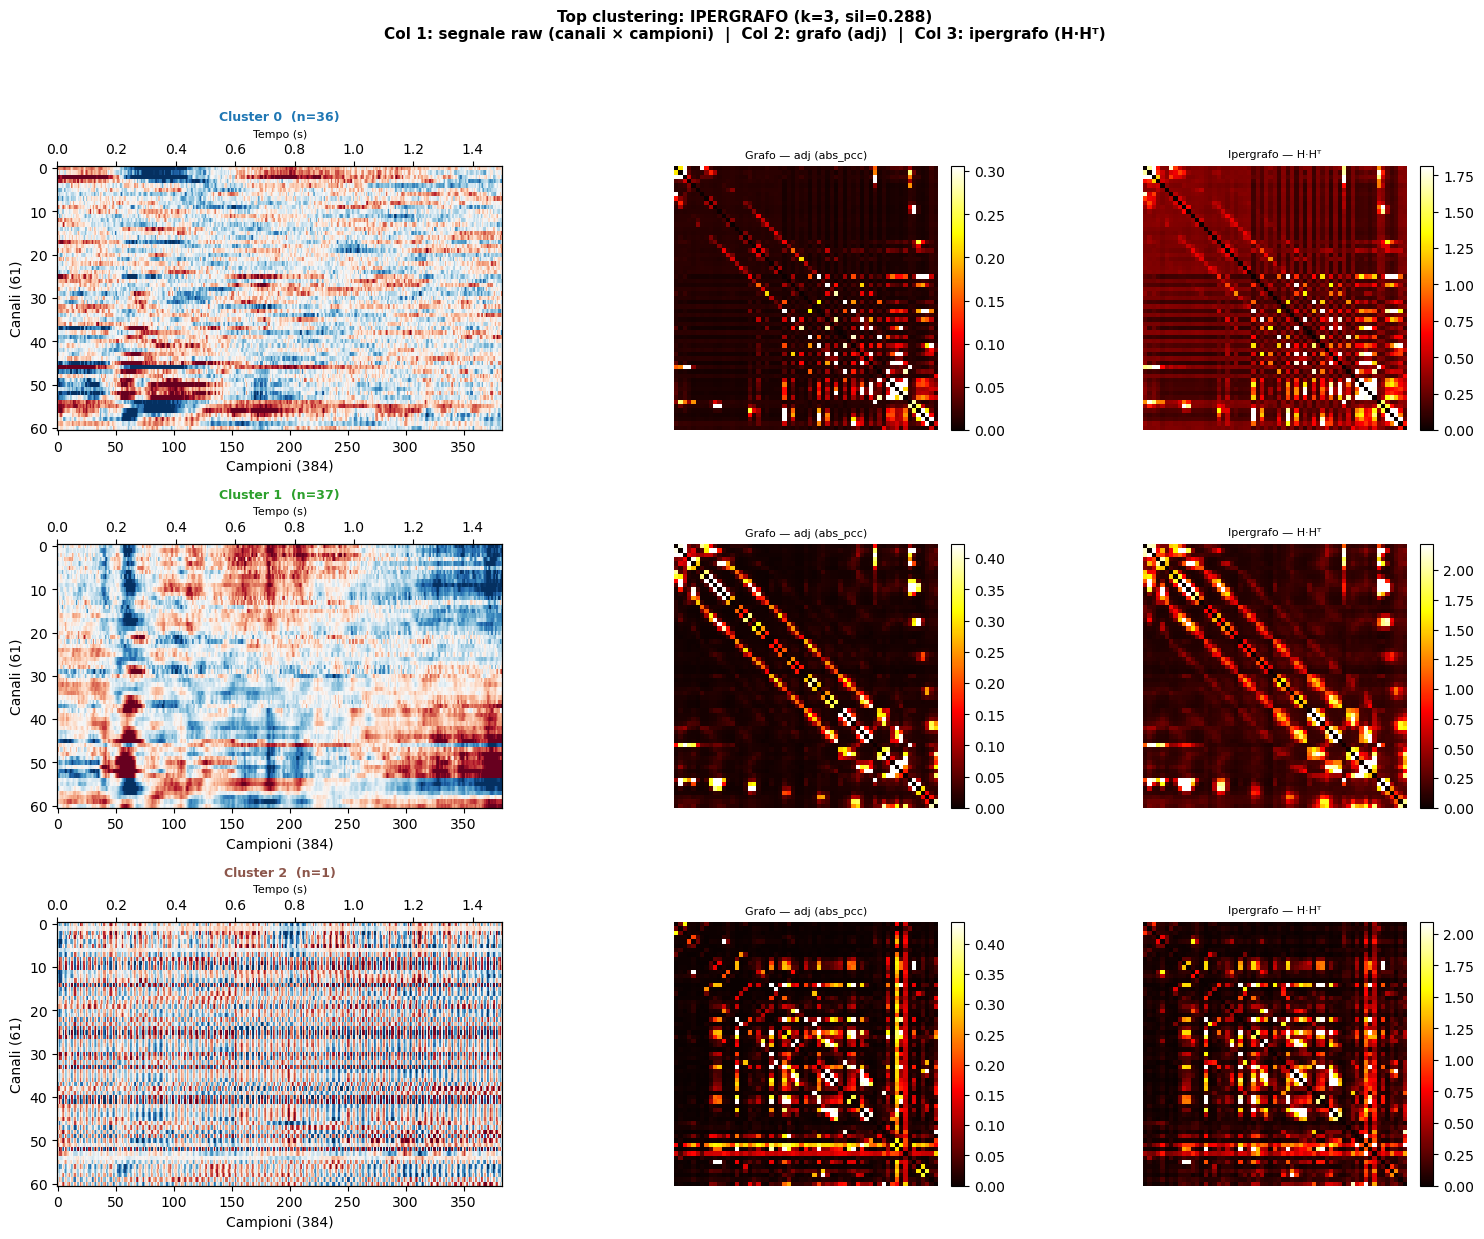

14:56:00 INFO     Plot §9 salvato


In [28]:
# ── Plot k × 3: raw | grafo | ipergrafo ──────────────────────────────────────
COLORS_TOP = plt.cm.tab10(np.linspace(0, 0.5, k_top))

fig, axes = plt.subplots(k_top, 3, figsize=(15, 4.2 * k_top))
fig.suptitle(
    f'Top clustering: {top_src}\n'
    f'Col 1: segnale raw (canali × campioni)  |  Col 2: grafo (adj)  |  Col 3: ipergrafo (H·Hᵀ)',
    fontsize=11, fontweight='bold'
)

for c in range(k_top):
    n_c   = int((LABELS_TOP == c).sum())
    color = COLORS_TOP[c]
    label = f'Cluster {c}  (n={n_c})'

    # ── Col 0: segnale raw ────────────────────────────────────────────────────
    ax0 = axes[c, 0]
    if cluster_raw[c] is not None:
        raw = cluster_raw[c]                          # (61, 384)
        vlim = np.percentile(np.abs(raw), 97)
        ax0.imshow(raw, aspect='auto', cmap='RdBu_r',
                   vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax0.set_xlabel('Campioni (384)')
        ax0.set_ylabel('Canali (61)')
        t_ax = ax0.twiny()
        t_ax.set_xlim(0, N_SAMP / 256)
        t_ax.set_xlabel('Tempo (s)', fontsize=8)
    else:
        ax0.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax0.transAxes)
    ax0.set_title(label, fontsize=9, color=color, fontweight='bold')

    # ── Col 1: grafo ──────────────────────────────────────────────────────────
    ax1 = axes[c, 1]
    if cluster_adj[c] is not None:
        adj = cluster_adj[c]
        im1 = ax1.imshow(adj, cmap='hot',
                         vmin=0, vmax=np.percentile(adj, 98),
                         interpolation='nearest')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.03)
        ax1.set_title(f'Grafo — adj ({METRIC})', fontsize=8)
    ax1.axis('off')

    # ── Col 2: ipergrafo ──────────────────────────────────────────────────────
    ax2 = axes[c, 2]
    if cluster_hht[c] is not None:
        hht = cluster_hht[c]
        im2 = ax2.imshow(hht, cmap='hot',
                         vmin=0, vmax=np.percentile(hht, 98),
                         interpolation='nearest')
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.03)
        ax2.set_title('Ipergrafo — H·Hᵀ', fontsize=8)
    ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIG_DIR / 'eeg16_top_cluster_raw_graph_hg.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Plot §9 salvato')


## §12 — Multi-metrica: clustering con wpli e plv (k=2 forzato)

Robustezza della separazione C0/C1 alle diverse metriche di connettività.

In [ ]:
METRICS_COMPARE = ['abs_pcc', 'wpli', 'plv']
ALL_FEATS_G  = {}
ALL_FEATS_H  = {}
ALL_LABELS_M = {}
ALL_SUBJ_M   = {}
ALL_SIL_M    = {}

for m in METRICS_COMPARE:
    cache = CKPT_DIR / f'feat_graph_{m}.npz'
    if cache.exists():
        _c = np.load(cache)
        feats, subjs = _c['feats'], _c['subj_ids'].tolist()
        log.info(f'{m}: cache caricata ({len(subjs)} soggetti)')
    else:
        log.info(f'{m}: calcolo feature...')
        idx_m = build_index(m)
        feat_list, subj_list = [], []
        for sid in tqdm(sorted(idx_m.keys()), desc=m, leave=False):
            adjs = []
            for p in idx_m[sid]:
                try:
                    d = torch.load(p, weights_only=False)
                    adj = d['adj'].float().numpy()
                    if adj.shape == (N_CHAN, N_CHAN):
                        adjs.append(adj)
                except Exception:
                    continue
            if len(adjs) >= 10:
                feat_list.append(np.mean(adjs, axis=0)[triu_idx])
                subj_list.append(sid)
        feats = np.array(feat_list); subjs = subj_list
        np.savez(cache, feats=feats, subj_ids=np.array(subjs))
    ALL_FEATS_G[m] = (feats, subjs)

    hg_cache = CKPT_DIR / f'feat_hg_{m}.npz'
    if hg_cache.exists():
        _hc = np.load(hg_cache)
        hht_feats, hht_subjs = _hc['feats'], _hc['subj_ids'].tolist()
    else:
        hht_feats, hht_subjs = np.zeros((0, N_TRIU)), []
    ALL_FEATS_H[m] = (hht_feats, hht_subjs)

    # Filtra soggetti esclusi
    feats_f, subjs_f = filter_subj(feats, subjs, EXCLUDE_SUBJ)

    # Clustering k=2 forzato
    X = StandardScaler().fit_transform(feats_f)
    Z = PCA(n_components=min(20, len(subjs_f) - 1), random_state=RANDOM_SEED).fit_transform(X)
    labels = KMeans(n_clusters=K_FORCED, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
    sil    = silhouette_score(Z, labels)
    ALL_LABELS_M[m] = labels
    ALL_SUBJ_M[m]   = subjs_f
    ALL_SIL_M[m]    = sil
    log.info(f'  {m}: k=2  sil={sil:.3f}  sizes={dict(zip(*np.unique(labels, return_counts=True)))}')

# ── ARI inter-metrica ─────────────────────────────────────────────────────────
n_m = len(METRICS_COMPARE)
ARI_MAT = np.zeros((n_m, n_m))
for i, m1 in enumerate(METRICS_COMPARE):
    for j, m2 in enumerate(METRICS_COMPARE):
        common = sorted(set(ALL_SUBJ_M[m1]) & set(ALL_SUBJ_M[m2]))
        l1 = np.array([ALL_LABELS_M[m1][ALL_SUBJ_M[m1].index(s)] for s in common])
        l2 = np.array([ALL_LABELS_M[m2][ALL_SUBJ_M[m2].index(s)] for s in common])
        ARI_MAT[i, j] = adjusted_rand_score(l1, l2)

for i, m1 in enumerate(METRICS_COMPARE):
    for j, m2 in enumerate(METRICS_COMPARE):
        if j > i:
            log.info(f'  {m1} vs {m2}: ARI={ARI_MAT[i,j]:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
COL_M = ['steelblue', 'darkorange', 'forestgreen']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Multi-metrica: robustezza k=2 clustering (senza P022)', fontsize=12, fontweight='bold')

ax = axes[0]
sils = [ALL_SIL_M[m] for m in METRICS_COMPARE]
bars = ax.bar(METRICS_COMPARE, sils, color=COL_M, alpha=0.85, edgecolor='white', width=0.5)
for bar, s in zip(bars, sils):
    ax.text(bar.get_x() + bar.get_width() / 2, s + 0.003, f'{s:.3f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Silhouette (k=2)'); ax.set_title('Silhouette per metrica')
ax.set_ylim(0, max(sils) * 1.3); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
im = ax2.imshow(ARI_MAT, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_xticks(range(n_m)); ax2.set_xticklabels(METRICS_COMPARE)
ax2.set_yticks(range(n_m)); ax2.set_yticklabels(METRICS_COMPARE)
ax2.set_title('ARI inter-metrica\n(ARI alto = stessa struttura robusta)')
for i in range(n_m):
    for j in range(n_m):
        ax2.text(j, i, f'{ARI_MAT[i,j]:.2f}', ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='white' if ARI_MAT[i, j] > 0.6 else 'black')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16b_multimetric_ari.png', dpi=150, bbox_inches='tight')
plt.show()

## §13 — Mappa differenza cluster: C1 − C0 per metrica

Per ogni metrica di connettività: heatmap differenza adj e H·Hᵀ.

In [ ]:
c_a, c_b = 0, 1   # k=2 forzato: sempre C0 vs C1
log.info(f'C{c_a} (n={(LABELS_TOP==c_a).sum()}) vs C{c_b} (n={(LABELS_TOP==c_b).sum()})')

def cluster_mean_mat_m(feats, subjs, cluster_idx):
    """Matrice media per cluster usando LABELS_TOP/SUBJ_TOP."""
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == cluster_idx]
    mats   = [vec_to_sym(feats[subjs.index(s)]) for s in subj_c if s in subjs]
    return np.mean(mats, axis=0) if mats else None

n_met = len(METRICS_COMPARE)
fig, axes = plt.subplots(2, n_met, figsize=(5 * n_met, 9))
fig.suptitle(
    f'Mappa differenza cluster C{c_b} − C{c_a}  ({top_src})\n'
    f'Rosso = C{c_b} più connesso  |  Blu = C{c_a} più connesso',
    fontsize=12, fontweight='bold'
)

for col, m in enumerate(METRICS_COMPARE):
    feats_m, subjs_m = ALL_FEATS_G[m]
    # Filtra P022 dalle feature per questa metrica
    feats_mf, subjs_mf = filter_subj(feats_m, subjs_m, EXCLUDE_SUBJ)
    adj_a = cluster_mean_mat_m(feats_mf, subjs_mf, c_a)
    adj_b = cluster_mean_mat_m(feats_mf, subjs_mf, c_b)

    ax = axes[0, col]
    if adj_a is not None and adj_b is not None:
        diff  = adj_b - adj_a
        d_lim = np.abs(diff).max() * 0.9
        im = ax.imshow(diff, cmap='RdBu_r', vmin=-d_lim, vmax=d_lim, interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        ax.set_title(f'{m}\nadj  C{c_b}−C{c_a}', fontsize=9, fontweight='bold')
    ax.axis('off')

    ax2 = axes[1, col]
    if m in ALL_FEATS_H:
        _hht_feats, _hht_subjs = ALL_FEATS_H[m]
        if len(_hht_feats) > 0:
            hf, hs = filter_subj(_hht_feats, _hht_subjs, EXCLUDE_SUBJ)
            hht_a = cluster_mean_mat_m(hf, hs, c_a)
            hht_b = cluster_mean_mat_m(hf, hs, c_b)
            if hht_a is not None and hht_b is not None:
                diff_h = hht_b - hht_a
                d_h    = np.abs(diff_h).max() * 0.9
                im2 = ax2.imshow(diff_h, cmap='RdBu_r', vmin=-d_h, vmax=d_h, interpolation='nearest')
                plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.03)
                ax2.set_title(f'{m}\nH·Hᵀ  C{c_b}−C{c_a}', fontsize=9, fontweight='bold')
            else:
                ax2.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax2.transAxes)
        else:
            ax2.text(0.5, 0.5, 'Cache H·Hᵀ\nnon trovata', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=9, color='grey', style='italic')
    ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16b_cluster_diff_map_multimetric.png', dpi=150, bbox_inches='tight')
plt.show()

## §14 — Metriche qualità segnale per cluster (k=2, senza P022)

Varianza, kurtosi, potenza gamma 30-60 Hz per C0 vs C1.
Se differiscono → la separazione è driven da qualità segnale (artefatti), non da IS.

14:56:39 INFO     Soggetti con qualità segnale: 74


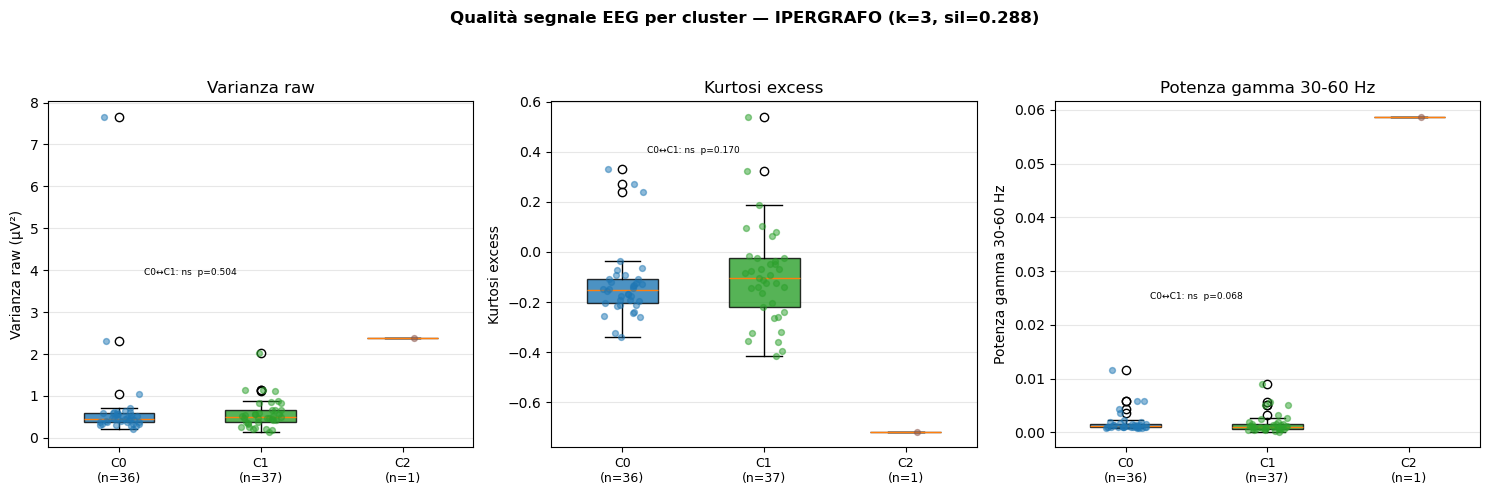


── Qualità segnale per cluster (IPERGRAFO (k=3, sil=0.288)) ──

  Cluster 0  (n=36):
    Varianza raw (µV²): mean=0.7202  std=1.2375  [0.2179, 7.6547]
    Kurtosi excess: mean=-0.1315  std=0.1430  [-0.3394, 0.3322]
    Potenza gamma 30-60 Hz: mean=0.0019  std=0.0021  [0.0008, 0.0116]

  Cluster 1  (n=37):
    Varianza raw (µV²): mean=0.5789  std=0.3594  [0.1510, 2.0362]
    Kurtosi excess: mean=-0.0972  std=0.1945  [-0.4134, 0.5382]
    Potenza gamma 30-60 Hz: mean=0.0017  std=0.0018  [0.0002, 0.0090]

  Cluster 2  (n=1):
    Varianza raw (µV²): mean=2.3839  std=nan  [2.3839, 2.3839]
    Kurtosi excess: mean=-0.7166  std=nan  [-0.7166, -0.7166]
    Potenza gamma 30-60 Hz: mean=0.0587  std=nan  [0.0587, 0.0587]


In [31]:
from scipy.stats import kurtosis as scipy_kurtosis
from scipy.signal import welch

FS         = 256
GAMMA_LOW  = 30
GAMMA_HIGH = 60

# ── Calcola metriche qualità per soggetto ─────────────────────────────────────
rows_q = []
for i, sid in enumerate(SUBJ_RAW):
    x = MEAN_RAW[i]   # (61, 384)

    var_mean   = float(np.var(x, axis=1).mean())
    kurt_mean  = float(np.mean(scipy_kurtosis(x, axis=1, fisher=True)))

    gamma_pows = []
    for ch in range(N_CHAN):
        f, psd = welch(x[ch], fs=FS, nperseg=min(128, N_SAMP))
        mask   = (f >= GAMMA_LOW) & (f <= GAMMA_HIGH)
        gamma_pows.append(float(psd[mask].mean()) if mask.any() else 0.0)
    gamma_mean = float(np.mean(gamma_pows))

    rows_q.append({'sid': sid, 'variance': var_mean,
                   'kurtosis': kurt_mean, 'gamma_power': gamma_mean})

df_qual = pd.DataFrame(rows_q)
df_qual['cluster'] = df_qual['sid'].apply(
    lambda s: int(LABELS_TOP[SUBJ_TOP.index(s)]) if s in SUBJ_TOP else np.nan
)
df_qual.dropna(subset=['cluster'], inplace=True)
df_qual['cluster'] = df_qual['cluster'].astype(int)
log.info(f'Soggetti con qualità segnale: {len(df_qual)}')

# ── Boxplot 1×3 ───────────────────────────────────────────────────────────────
QUAL_COLS = [
    ('variance',    'Varianza raw (µV²)'),
    ('kurtosis',    'Kurtosi excess'),
    ('gamma_power', 'Potenza gamma 30-60 Hz'),
]
COLORS_TOP_Q = plt.cm.tab10(np.linspace(0, 0.5, k_top))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Qualità segnale EEG per cluster — {top_src}', fontsize=12, fontweight='bold')

for ax, (col, label) in zip(axes, QUAL_COLS):
    data = [df_qual[df_qual['cluster'] == c][col].values for c in range(k_top)]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5, notch=False)
    for patch, color in zip(bp['boxes'], COLORS_TOP_Q):
        patch.set_facecolor(color); patch.set_alpha(0.8)

    # Overlay punti
    for c, d in enumerate(data):
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(d))
        ax.scatter(np.full(len(d), c + 1) + jitter, d,
                   color=COLORS_TOP_Q[c], s=18, alpha=0.5, zorder=3)

    ax.set_xticklabels([f'C{c}\n(n={len(data[c])})' for c in range(k_top)], fontsize=9)
    ax.set_title(label.split(' (')[0]); ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

    # p-value Mann-Whitney su tutte le coppie
    all_flat = np.concatenate([d for d in data if len(d)])
    y_top = np.percentile(all_flat, 99) if len(all_flat) else 1
    for off, (ci, cj) in enumerate([(ci, cj) for ci in range(k_top) for cj in range(ci+1, k_top)]):
        if len(data[ci]) >= 2 and len(data[cj]) >= 2:
            _, pval = mannwhitneyu(data[ci], data[cj], alternative='two-sided')
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            ax.annotate(f'C{ci}↔C{cj}: {star}  p={pval:.3f}',
                        xy=((ci + cj) / 2 + 1, y_top * (1.02 + 0.06 * off)),
                        fontsize=6.5, ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16_signal_quality_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stampa stats ──────────────────────────────────────────────────────────────
print(f'\n── Qualità segnale per cluster ({top_src}) ──')
for c in range(k_top):
    sub = df_qual[df_qual['cluster'] == c]
    print(f'\n  Cluster {c}  (n={len(sub)}):')
    for col, label in QUAL_COLS:
        print(f'    {label}: mean={sub[col].mean():.4f}  std={sub[col].std():.4f}'
              f'  [{sub[col].min():.4f}, {sub[col].max():.4f}]')


## §15 — Mappa cervello: topomap + grafo connettività C0 vs C1

Visualizzazione topografica sulla superficie del cranio delle differenze di connettività tra i due cluster.

**Riga 1 — Topomaps** (interpolazione continua sulla calotta cranica):
- C0: forza media di ogni nodo (media riga adj_C0)
- C1: forza media di ogni nodo (media riga adj_C1)
- Differenza C1−C0: rosso = C1 più connesso, blu = C0

**Riga 2 — Grafi di connettività** (top N edges disegnati sulla proiezione 2D):
- C0: top 30 connessioni più forti
- C1: top 30 connessioni più forti
- Differenza: edges dove C1>C0 (rosso) e C0>C1 (blu)

In [ ]:
# §15 — Mappa cervello: topomap + grafo connettività C0 vs C1
import mne
from matplotlib.lines import Line2D

# ── Nomi canali con alias MNE-compatibili ─────────────────────────────────────
# T3→T7, T4→T8, T5→P7, T6→P8, FP2→Fp2 già nel mapping standard
CHAN_NAMES_MNE = [
    'A1','AF7','AF3','Fp1','Fp2','AF4','AF8','A2',      # E00-E07
    'F7', 'F5', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8',   # E08-E15
    'FT7','FC5','FC3','FC1','FC2','FC4','FC6','FT8',    # E16-E23
    'T7', 'C5', 'C3', 'C1', 'C2', 'C4', 'C6', 'T8',   # E24-E31
    'TP7','CP5','CP3','CP1','CP2','CP4','CP6','TP8',    # E32-E39
    'P7', 'P5', 'P3', 'P1', 'P2', 'P4', 'P6', 'P8',   # E40-E47
    'FPz','PO7','PO3','O1', 'O2', 'PO4','PO8','Oz',    # E48-E55
    'AFz','Fz', 'FCz','Cz', 'CPz'                      # E56-E60
]
assert len(CHAN_NAMES_MNE) == N_CHAN

# A1/A2 = mastoid reference — nessuna posizione in standard_1020
SKIP_TOPOMAP   = {0, 7}
MASTOID_APPROX = {0: (-0.085, -0.012), 7: (0.085, -0.012)}

montage = mne.channels.make_standard_montage('standard_1020')
pos3d_d = montage.get_positions()['ch_pos']

elec_xy = np.full((N_CHAN, 2), np.nan)
for e_idx, ch in enumerate(CHAN_NAMES_MNE):
    if e_idx in MASTOID_APPROX:
        elec_xy[e_idx] = MASTOID_APPROX[e_idx]
    elif ch in pos3d_d:
        p = pos3d_d[ch]
        elec_xy[e_idx] = [p[0], p[1]]
    else:
        log.warning(f'  {ch} (E{e_idx:02d}) non trovato nel montage')

# Maschera topomap (esclude mastoid A1/A2)
topo_mask = np.array([e not in SKIP_TOPOMAP and not np.isnan(elec_xy[e, 0])
                      for e in range(N_CHAN)])
topo_idx  = np.where(topo_mask)[0]
topo_pos  = elec_xy[topo_idx]   # (n_topo, 2) in metres

# Maschera connectivity (include tutto ciò che ha posizione valida)
conn_mask = ~np.isnan(elec_xy[:, 0])
conn_idx  = np.where(conn_mask)[0]
conn_pos  = elec_xy[conn_idx]
orig2conn = {orig: i for i, orig in enumerate(conn_idx)}

log.info(f'Topomap canali: {topo_mask.sum()}  |  Connectivity canali: {conn_mask.sum()}')

# Forza media per nodo (media riga matrice adj)
strength_C0 = adj_C0.mean(axis=1)
strength_C1 = adj_C1.mean(axis=1)
TOP_EDGES   = 30

# ── Funzione topomap MNE ──────────────────────────────────────────────────────
def draw_topo(ax, values, title, cmap='Reds', sym=False):
    data_t = values[topo_idx]
    if sym:
        vlim = np.abs(data_t).max() * 0.95 + 1e-10
        vmin, vmax = -vlim, vlim
    else:
        vmin = np.percentile(data_t, 2)
        vmax = np.percentile(data_t, 98) + 1e-10
    try:
        mne.viz.plot_topomap(
            data_t, topo_pos, axes=ax, show=False,
            cmap=cmap, vmin=vmin, vmax=vmax,
            contours=4, extrapolate='head',
            outlines='head', image_interp='cubic',
        )
        cb_im = ax.images[0] if ax.images else None
        if cb_im is not None:
            plt.colorbar(cb_im, ax=ax, fraction=0.046, pad=0.03, shrink=0.85)
    except Exception as e:
        log.warning(f'plot_topomap fallito ({e}) — fallback scatter')
        sc = ax.scatter(topo_pos[:, 0], topo_pos[:, 1], c=data_t,
                        cmap=cmap, vmin=vmin, vmax=vmax, s=90, zorder=3,
                        edgecolors='white', linewidths=0.5)
        for i, e_idx in enumerate(topo_idx):
            ax.annotate(CHAN_NAMES_MNE[e_idx], topo_pos[i], fontsize=4,
                        xytext=(1, 1), textcoords='offset points', alpha=0.7)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03, shrink=0.85)
    ax.set_title(title, fontsize=10, fontweight='bold')

# ── Funzione grafo connettività ───────────────────────────────────────────────
def draw_conn(ax, adj_mat, title, edge_color='#1f77b4',
              sym_diff=False, diff_mat=None):
    r_head = 0.095
    ax.set_aspect('equal')
    margin = 0.015
    ax.set_xlim(-r_head - margin, r_head + margin)
    ax.set_ylim(-r_head - margin, r_head + margin)
    ax.axis('off')

    # Testa + naso
    th = np.linspace(0, 2 * np.pi, 300)
    ax.plot(r_head * np.cos(th), r_head * np.sin(th),
            color='#999999', lw=1.2, alpha=0.5, zorder=0)
    nose_x = np.array([-0.008, 0, 0.008])
    nose_y = np.array([r_head, r_head + 0.015, r_head])
    ax.plot(nose_x, nose_y, color='#999999', lw=1.5, alpha=0.5, zorder=0)

    # Matrice di riferimento per threshold
    ref = diff_mat if (sym_diff and diff_mat is not None) else adj_mat
    upper_ref = np.abs(np.triu(ref, k=1))
    flat_v    = upper_ref.flatten()
    if flat_v.max() < 1e-10:
        ax.set_title(title + '\n(nessun edge)', fontsize=10)
        return
    n_edges_show = min(TOP_EDGES * (2 if sym_diff else 1), int((flat_v > 0).sum()) - 1)
    thresh  = np.sort(flat_v)[::-1][n_edges_show]
    max_v   = flat_v.max()

    # Edges
    for i in range(N_CHAN):
        for j in range(i + 1, N_CHAN):
            w = abs(ref[i, j])
            if w < thresh:
                continue
            if i not in orig2conn or j not in orig2conn:
                continue
            xi, yi = conn_pos[orig2conn[i]]
            xj, yj = conn_pos[orig2conn[j]]
            alpha_e = float(0.15 + 0.65 * (w / max_v))
            lw_e    = float(0.4  + 3.5  * (w / max_v))
            col_e   = ('crimson' if ref[i, j] > 0 else 'steelblue') if sym_diff else edge_color
            ax.plot([xi, xj], [yi, yj], '-', color=col_e,
                    alpha=alpha_e, linewidth=lw_e, zorder=1)

    # Nodi
    node_s  = adj_mat.mean(axis=1)
    ns_max  = node_s.max() + 1e-10
    nv_lim  = np.abs(net_diff_per_elec).max() + 1e-10
    nc_map  = plt.cm.RdBu_r

    for e_idx in conn_idx:
        x, y = conn_pos[orig2conn[e_idx]]
        size = float(18 + 55 * (node_s[e_idx] / ns_max))
        if sym_diff:
            nv    = net_diff_per_elec[e_idx]
            c_node = nc_map(0.5 + 0.5 * nv / nv_lim)
        else:
            c_node = edge_color
        ax.scatter(x, y, s=size, c=[c_node], alpha=0.9, zorder=3,
                   edgecolors='white', linewidths=0.5)
        if e_idx not in SKIP_TOPOMAP:
            ax.annotate(CHAN_NAMES_MNE[e_idx], (x, y), fontsize=3.8,
                        xytext=(1.5, 1.5), textcoords='offset points',
                        alpha=0.75, zorder=4)

    ax.set_title(title, fontsize=10, fontweight='bold')

# ── Layout 2×3 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    f'Mappa cervello — Connettività C0 vs C1  ({top_src})\n'
    f'Riga 1: topomap forza nodo  |  Riga 2: top {TOP_EDGES} connessioni',
    fontsize=13, fontweight='bold'
)

# Riga 0 — topomaps
draw_topo(axes[0, 0], strength_C0,
          f'C0 — forza connettività\n(n={n_c0})', cmap='Reds')
draw_topo(axes[0, 1], strength_C1,
          f'C1 — forza connettività\n(n={n_c1})', cmap='Reds')
draw_topo(axes[0, 2], net_diff_per_elec,
          'Differenza C1 − C0\n(rosso=C1 più connesso, blu=C0)', cmap='RdBu_r', sym=True)

# Riga 1 — connectivity graphs
draw_conn(axes[1, 0], adj_C0,
          f'C0: top {TOP_EDGES} connessioni', edge_color='#1f77b4')
draw_conn(axes[1, 1], adj_C1,
          f'C1: top {TOP_EDGES} connessioni', edge_color='#d62728')
draw_conn(axes[1, 2], adj_C0,
          f'Differenza: ±{TOP_EDGES} edges\n(rosso=C1>C0, blu=C0>C1)',
          sym_diff=True, diff_mat=diff_adj)

# Legenda pannello differenza
axes[1, 2].legend(
    handles=[Line2D([0],[0], color='crimson',   lw=2.5, label='C1 > C0'),
             Line2D([0],[0], color='steelblue', lw=2.5, label='C0 > C1')],
    loc='lower right', fontsize=8, framealpha=0.75
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(FIG_DIR / 'eeg16b_brain_connectivity_map.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('§15 brain connectivity map salvato')